# Загрузка данных и первичный осмотр

## Импортируем необходимые библиотеки: ##

In [469]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка учебного датасета: #

In [470]:
df = pd.read_csv(r"D:\IAI_course\abrician_course\homeworks\HW02\data\S02-hw-dataset.csv")

## Ввод данных из датасета: ##

In [471]:
print(df.head())#вывод первых строк
print(df.info())#информация о столбцах
print(df.describe())#базовые описательные статистики 

   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB
None
         user_id         age  purchases      revenue
count  41.000000   39.000000  41.000000    41.000000
mean   20.243902   36.512821   4.829268   820.048780
std    11.659289   18.304259   2.710189   613.127269
min     1.000000    5.000000  -1.000000     0.000000
25%    10.000000

# Пропуски, дубликаты и базовый контроль качества

## Пропуски и дубликаты: ##

### Подсчeт доли пропусков в каждом столбце:

In [472]:
df.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

### Проверка наличия полностью дублирующих строк:

In [473]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
dtype: bool

## Поиск подозрительных случаев: ##

In [474]:
# Находим все строки, где количество меньше нуля
suspicious_quantity = df[df['purchases'] < 0]
print("Подозрительные строки с количеством < 0:")
print(suspicious_quantity)

Подозрительные строки с количеством < 0:
   user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785


In [475]:
# Находим все строки, где возраст превышает 100
suspicious_age = df[df['age'] > 100]
print("Подозрительные строки с возрастом > 100:")
print(suspicious_age)

Подозрительные строки с возрастом > 100:
   user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785


In [476]:
# Находим строки, где доход равен 0 И количество > 0
contradiction_case = df[(df['revenue'] == 0) & (df['purchases'] > 0)]
print("Логическое противоречие: Доход = 0 при продажах > 0:")
print(contradiction_case)

Логическое противоречие: Доход = 0 при продажах > 0:
    user_id   age country  purchases  revenue
10       11  24.0      US          4        0


При анализе данных датасета, были выявлены такие проблемы качества данных как: найдены строки с некоректными данными(отритацательные значения там где этого быть не должно, а также данные не корректно большие для выбранной категории), а также логические противоречия(нулевой доход, при не нулевых продажах)

# Базовый EDA: группировки, агрегаты и частоты

## Посчитать частоты для стран: ##

In [477]:
# абсолютные частоты
df['country'].value_counts()


country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64

In [478]:
# относительные (доля)
df['country'].value_counts(normalize=True)

country
RU    0.317073
FR    0.292683
US    0.195122
DE    0.146341
CN    0.048780
Name: proportion, dtype: float64

## Выполним осмысленную группировку с агрегатами через groupby: ##

In [479]:
grouped = df.groupby('country').agg(
    n_users = ('user_id', 'count'),
    avg_age = ('age', 'mean'),
    avg_revenue = ('revenue', 'mean'),
    total_purchases = ('purchases', 'sum')
).reset_index()

grouped.sort_values('avg_revenue', ascending=False)

,country,n_users,avg_age,avg_revenue,total_purchases
1,DE,6,34.600000,1445.500000,39
0,CN,2,24.000000,1054.000000,9
3,RU,13,30.076923,790.076923,62
2,FR,12,46.250000,675.916667,51
4,US,8,36.714286,557.375000,37


## Вводим группировку "возрастные группы": ##

In [480]:
# Оставляем строки, где age в диапазоне 16–65 ИЛИ age == NaN
df = df[(df['age'].between(16, 65)) | (df['age'].isna())]

In [481]:
#Создание возрастных коридоров
bins = [16, 25, 35, 50, 65]
labels = ['16–25', '25–35', '35–50', '50–65']

df['age_category'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False  # левая граница включена, правая исключена (16–25, 25–35, и т.д.)
)

In [482]:
#Проверка результата
print(df[['age', 'age_category']].head(20))

     age age_category
0   25.0        25–35
1   24.0        16–25
2   52.0        50–65
3   31.0        25–35
4    NaN          NaN
6   46.0        35–50
7   28.0        25–35
8   39.0        35–50
9   24.0        16–25
10  24.0        16–25
11  20.0        16–25
12   NaN          NaN
13  36.0        35–50
14  57.0        50–65
15  22.0        16–25
16  32.0        25–35
17  24.0        16–25
18  47.0        35–50
19  31.0        25–35
21  33.0        25–35


## Анализируем результаты: ##

In [483]:
#Средний revenue и purchases по возрастным группам
grouped_age = df.groupby('age_category', observed=True).agg({
    'revenue': ['mean', 'sum', 'count'],
    'purchases': ['mean', 'sum']
})

grouped_age


revenue              purchases    
                     mean    sum count      mean sum
age_category                                        
16–25          617.100000   6171    10  4.700000  47
25–35         1009.600000  10096    10  5.300000  53
35–50          870.545455   9576    11  4.181818  46
50–65          596.666667   3580     6  5.000000  30

In [484]:
#приведем к более красивому виду
grouped_age.columns = [
    'avg_revenue', 'sum_revenue', 'users_in_group',
    'avg_purchases', 'sum_purchases'
]

grouped_age

,avg_revenue,sum_revenue,users_in_group,avg_purchases,sum_purchases
age_category,,,,,
16–25,617.100000,6171,10,4.700000,47
25–35,1009.600000,10096,10,5.300000,53
35–50,870.545455,9576,11,4.181818,46
50–65,596.666667,3580,6,5.000000,30


In [485]:
#Сортировка по среднему revenue
grouped_age.sort_values('avg_revenue', ascending=False)

,avg_revenue,sum_revenue,users_in_group,avg_purchases,sum_purchases
age_category,,,,,
25–35,1009.600000,10096,10,5.300000,53
35–50,870.545455,9576,11,4.181818,46
16–25,617.100000,6171,10,4.700000,47
50–65,596.666667,3580,6,5.000000,30


In [486]:
#Частоты пользователей по возрастным группам
df['age_category'].value_counts(dropna=False)

age_category
35–50    11
16–25    10
25–35    10
50–65     6
NaN       2
Name: count, dtype: int64

В результате работы этого EDA мы посчитали частоты(абсолютные и относительные) для стран и возрастных групп (предварительно их сгруппировав); выполнили группировку стран по n_users(количеству покупателей), avg_age(среднему возрасту), avg_revenue(среднему доходу), total_purchases (среднему колличеству продаж), это помогло нам понять какие страны доминируют в том или ином аспекте; по возрастным группым мы тоже сделали группировки, которые могут нам помочь в поиске доминирующих групп в том или ином авспекте(например мы отсортировали по вреднему доходу).
По результатам нашего анализа:
-по странам:
страна с самым большим колличкством покупателей - RU(россия) (с долей 0.31 от общего колличества покупателей);
наибольшее колличество покупок у FR(франции);
наибольший доход от DE(германия);
и тд.
-по возрастам:
самая многочисленная группа - 35 - 50;
c самым большим средним и общим доходом - 25–35;
с самым большим средним и общим колличеством продаж - 25–35;


# Визуализация данных в Matplotlib

In [487]:
#Импортируем matplotlib
import matplotlib.pyplot as plt

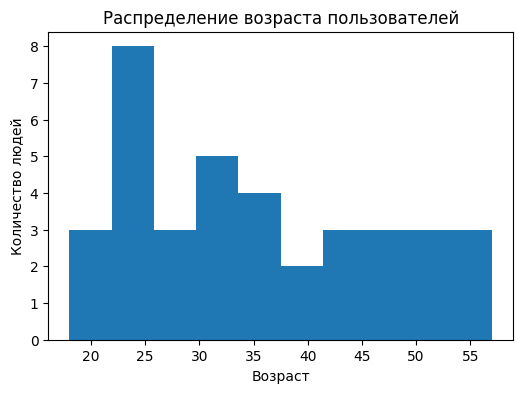

In [488]:
#Гистограммa для возроста
plt.figure(figsize=(6,4))
plt.hist(df['age'].dropna(), bins=10)
plt.xlabel('Возраст')
plt.ylabel('Количество людей')
plt.title('Распределение возраста пользователей')
#Cохраним этот график в папку figures
plt.savefig('figures/age_hist.png', dpi=150)

plt.show()

 На гистограмме видно, что возраст пользователей распределён в диапазоне примерно от 20 до 55 лет. Значения вне этого промежутка либо отсутствуют, либо встречаются крайне редко и не отображаются из-за масштаба.Основная концентрация пользователей приходится на возраст 25-40 лет, что говорит о преобладании молодой и активной аудитории.


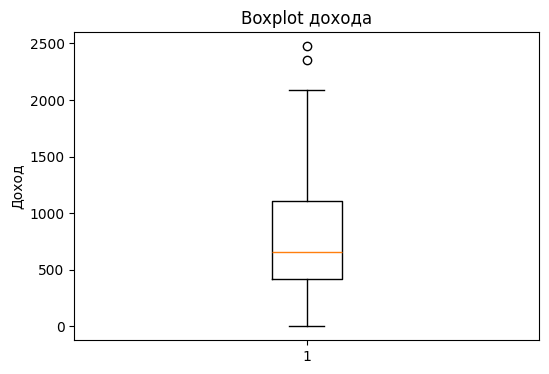

In [489]:
#Bozplot для дохода
plt.figure(figsize=(6,4))
plt.boxplot(df['revenue'])
plt.ylabel('Доход')
plt.title('Boxplot дохода')

plt.show()

Боксплот показывает, что доход пользователей распределён неравномерно: есть несколько заметных выбросов, где значение дохода намного выше основного диапазона.Основная часть значений лежит ближе к нижней границе, что говорит о высокой вариативности доходов.

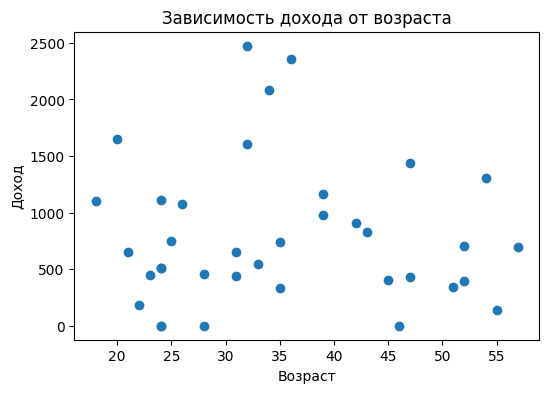

In [490]:
#Scatter plot для возраста и дохода
plt.figure(figsize=(6,4))
plt.scatter(df['age'], df['revenue'])
plt.xlabel('Возраст')
plt.ylabel('Доход')
plt.title('Зависимость дохода от возраста')

plt.show()


Диаграмма показывает общую тенденцию: с ростом количества покупок доход обычно увеличивается.
Однако точки сильно разбросаны. Это может быть вызвано разной ценой товаров или ошибками в данных.